<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

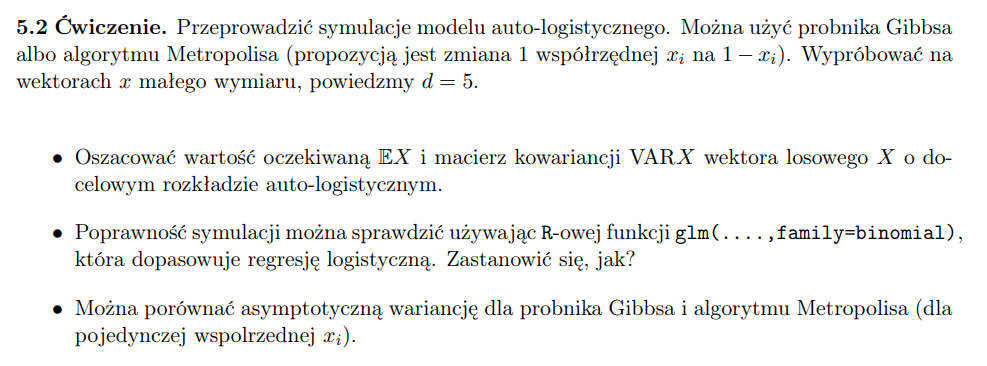

## Auto-logistic Model Simulation
---

The auto-logistic model describes a joint distribution for a binary vector $X = (X_0, \dots, X_{d-1}) \in \{0, 1\}^d$. According to the suggested parameters, the main effects are $\alpha_{ii} = +1$ and the pairwise interactions are $\alpha_{ij} = -1$ (for $i \neq j$).

### 1. Gibbs Sampler
To implement the Gibbs sampler, we use the conditional distribution of a single coordinate $X_i$ given all other coordinates $X_{-i}$:

$$P(X_i = 1 | X_{-i}) = \text{logit}^{-1}\left( \alpha_{ii} + \sum_{j \neq i} \alpha_{ij} X_j \right)$$

### 2. Metropolis Algorithm
For the Metropolis algorithm, we randomly select an index $i \sim U(0, d-1)$ and propose a flipped state $X'_i = 1 - X_i$. The acceptance probability is $\min(1, \exp(\Delta E))$, where:

$$\Delta E = \left(\alpha_{ii} + \sum_{j \neq i} \alpha_{ij} X_j \right)(X'_i - X_i)$$

### 3. Logistic Regression
The conditional distribution $P(X_i = 1 | X_{-i})$ takes the exact mathematical form of a logistic regression, where $X_i$ is the response variable and $X_{-i}$ are the predictors. If our MCMC simulation is correct, fitting a logistic regression model to predict $X_0$ from the remaining coordinates should yield estimated coefficients that closely match the true parameters: intercept $\approx +1$ and slopes $\approx -1$.

## Simulations
---

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import time

In [2]:
# setup
np.random.seed(42)
d = 5

# alpha_ii = +1
alpha_true = np.ones(d) * 1.0

# alpha_ij = -1
beta_true = -np.ones((d, d))
np.fill_diagonal(beta_true, 0.0)

def expit(x):
    """Logit inverse"""
    return 1.0 / (1.0 + np.exp(-x))

In [3]:
# samplers


# Gibbs sampler
def run_gibbs_sampler(n_iter):
    samples = np.zeros((n_iter, d), dtype=int)
    x = np.random.randint(0, 2, size=d)

    for t in range(n_iter):
        for i in range(d):
            interaction = np.dot(beta_true[i, :], x)
            prob_1 = expit(alpha_true[i] + interaction)
            x[i] = np.random.binomial(1, prob_1)
        samples[t, :] = x
    return samples

# Metropolis sampler
def run_metropolis(n_iter):
    samples = np.zeros((n_iter, d), dtype=int)
    x = np.random.randint(0, 2, size=d)

    for t in range(n_iter):
        i = np.random.randint(0, d)
        x_prop = x[i] ^ 1 # XOR reverses bit

        interaction = np.dot(beta_true[i, :], x)

        delta_x = x_prop - x[i]
        delta_E = (alpha_true[i] + interaction) * delta_x

        if delta_E >= 0 or np.log(np.random.rand()) < delta_E:
            x[i] = x_prop

        samples[t, :] = x
    return samples

In [4]:
# simulations and metrics calculations for Gibbs
print("Generating samples using Gibbs sampler")
N = 50000
burn_in = 5000
samples_gibbs = run_gibbs_sampler(N + burn_in)[burn_in:]

mean_X = np.mean(samples_gibbs, axis=0)
cov_X = np.cov(samples_gibbs, rowvar=False)

print("\nEstimated E[X]:")
print(np.round(mean_X, 3))
print("\nEstimated Covariance Matrix VAR[X]:")
print(np.round(cov_X, 3))

Generating samples using Gibbs sampler

Estimated E[X]:
[0.385 0.386 0.383 0.383 0.384]

Estimated Covariance Matrix VAR[X]:
[[ 0.237 -0.03  -0.029 -0.032 -0.03 ]
 [-0.03   0.237 -0.028 -0.033 -0.03 ]
 [-0.029 -0.028  0.236 -0.031 -0.032]
 [-0.032 -0.033 -0.031  0.236 -0.029]
 [-0.03  -0.03  -0.032 -0.029  0.237]]


In [5]:
# we check the correctness of simulation with logistic regression
y_glm = samples_gibbs[:, 0]
X_glm = samples_gibbs[:, 1:]

X_glm_with_intercept = sm.add_constant(X_glm)
model = sm.GLM(y_glm, X_glm_with_intercept, family=sm.families.Binomial())
result = model.fit()

true_params_X0 = [alpha_true[0]] + list(beta_true[0, 1:])
estimated_params = result.params

comparison_df = pd.DataFrame({
    "True Parameters": true_params_X0,
    "GLM Estimation": estimated_params
}, index=["alpha_00", "alpha_01", "alpha_02", "alpha_03", "alpha_04"])

display(comparison_df.round(3))


,True Parameters,GLM Estimation
alpha_00,1.0,0.996
alpha_01,-1.0,-0.981
alpha_02,-1.0,-0.970
alpha_03,-1.0,-1.040
alpha_04,-1.0,-0.989


In [6]:
# comparison of asymptotic variance
K = 2000
M = 500

def get_asymptotic_variance(sampler_func):
    path_sums = np.zeros(K)
    for k in range(K):
        chain = sampler_func(M + 50)[50:]
        path_sums[k] = np.sum(chain[:, 0])

    trajectory_means = path_sums / M
    return M * np.var(trajectory_means, ddof=1)

var_as_gibbs = get_asymptotic_variance(run_gibbs_sampler)
print(f"Gibbs: σ²_as = {var_as_gibbs:.4f}")

var_as_metropolis = get_asymptotic_variance(run_metropolis)
print(f"Metropolis: σ²_as = {var_as_metropolis:.4f}")

Gibbs: σ²_as = 0.2801
Metropolis: σ²_as = 1.4997
